In [1]:
import sys
from pathlib import Path
from typing import Dict, Any

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

PYTHONWARNINGS = "ignore:In 2.9.*:UserWarning:torchaudio._backend.utils,ignore:'pin_memory'.*:UserWarning:torch.utils.data.dataloader"

current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "esc50" / "data")

print(f"Current directory: {current_dir}")
print(f"Project root: {project_root}")
print(f"Data root: {data_root}")

Current directory: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/notebooks/esc50
Project root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4
Data root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data


In [2]:
from src.models.v2.build_model import BlockConfig
from esc50_task import ESC50Task


def create_block_cfg_ctor(
    core: str,
    dropout: float,
    mlp_ratio: float,
    droppath_final: float,
    layerscale_init: float,
    residual_gain: float,
    pool: str,
    # S4-specific params
    d_state: int = 128,
    channels: int = 4,
    bidirectional: bool = True,
    mode: str = 's4d',
    dt_min: float = 0.001,
    dt_max: float = 0.1,
):
    """Create a block config constructor with the given hyperparameters."""

    def block_cfg_ctor(theta: int) -> BlockConfig:
        return BlockConfig(
            kind=core,
            # S4 parameters
            d_state=d_state,
            channels=channels,
            bidirectional=bidirectional,
            mode=mode,
            dt_min=dt_min,
            dt_max=dt_max,
            # Common parameters
            dropout=dropout,
            mlp_ratio=mlp_ratio,
            droppath_final=droppath_final,
            layerscale_init=layerscale_init,
            residual_gain=residual_gain,
            pool=pool,
        )
    return block_cfg_ctor

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


In [3]:
"""Configuration"""
import torch

args: Dict[str, Any] = {
    # data
    "data_root": data_root,
    "batch": 32,  # Reduced from 64 for MPS memory constraints
    "data_loader_kwargs": {
        "num_workers": 0,  # Critical for Mac - avoids slowdown
        "fold_val": 1,
        "feature": "melspec",
        "sample_rate": 16000,
        "n_mels": 128,
        "hop_length": 160,
        "n_fft": 512,
        "target_num_frames": 500,
        "augment": True,
        "pin_memory": False,
        "persistent_workers": False,
    },

    # training
    "epochs": 100,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": True,
    "save_dir": "./runs/esc50_s4_task",
    "warmup_epochs": 10,
    "patience": 10,
    "min_delta": 0.0,
    "early_key": "acc",  # Use accuracy for early stopping

    # model scaffold - Reduced for MPS memory
    "d_model": 256,
    "depth": 4,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.05,
    "layerscale_init": 1e-2,
    "residual_gain": 1.0,
    "pool": "mean",

    # S4-specific parameters - Optimized for MPS
    "core": "s4",
    "d_state": 64,
    "channels": 2,
    "bidirectional": False,  # Disabled to save memory
    "mode": 's4d',
    "dt_min": 0.001,
    "dt_max": 0.1,
}

args["block_cfg_ctor"] = create_block_cfg_ctor(
    core=args["core"],
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
    d_state=args["d_state"],
    channels=args["channels"],
    bidirectional=args["bidirectional"],
    mode=args["mode"],
    dt_min=args["dt_min"],
    dt_max=args["dt_max"],
)

# Device selection
if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("Using MPS (Apple Silicon)")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
    print("Using CUDA")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False
    print("Using CPU")


Using MPS (Apple Silicon)


In [ ]:
import os
from src.train_utils.trainer import Trainer

task = ESC50Task()

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"✅ Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...
✅ Loaded checkpoint from epoch 78
📊 Val metrics: {'loss': 2.1794225215911864, 'time_s': 3.8839452499996696, 'acc': 0.56}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


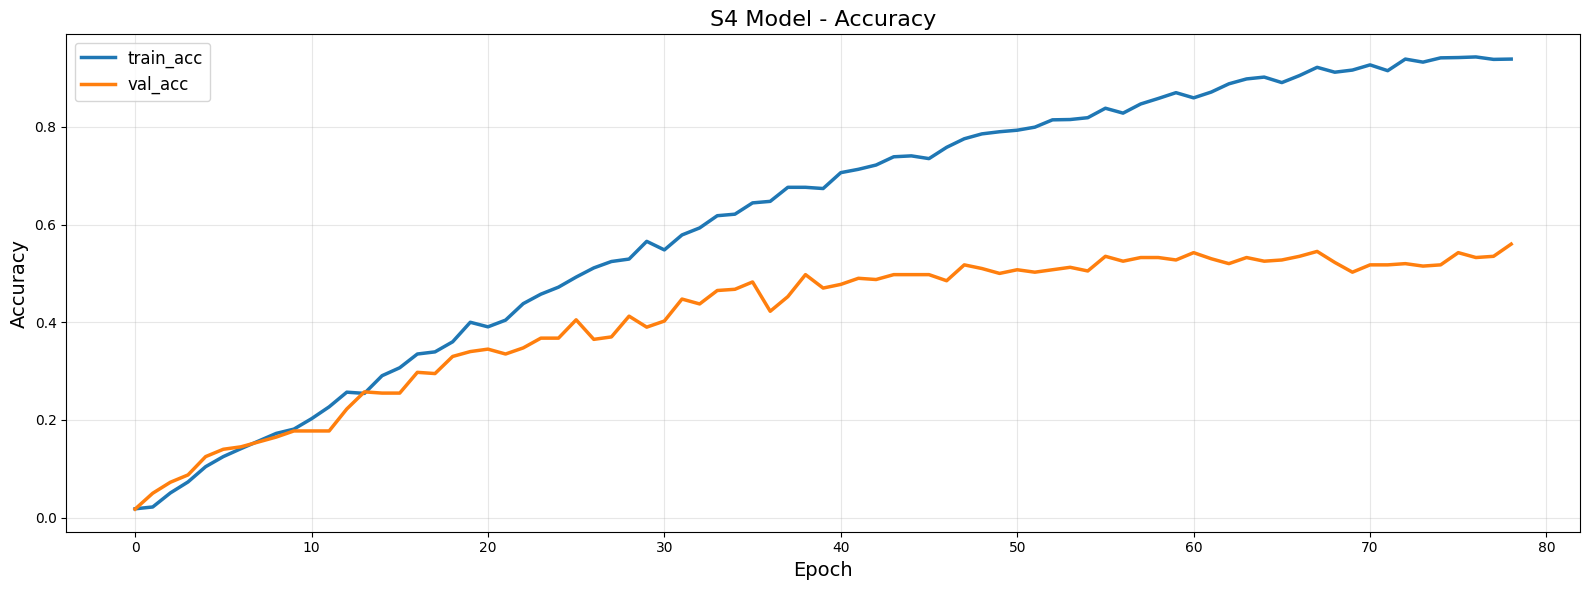

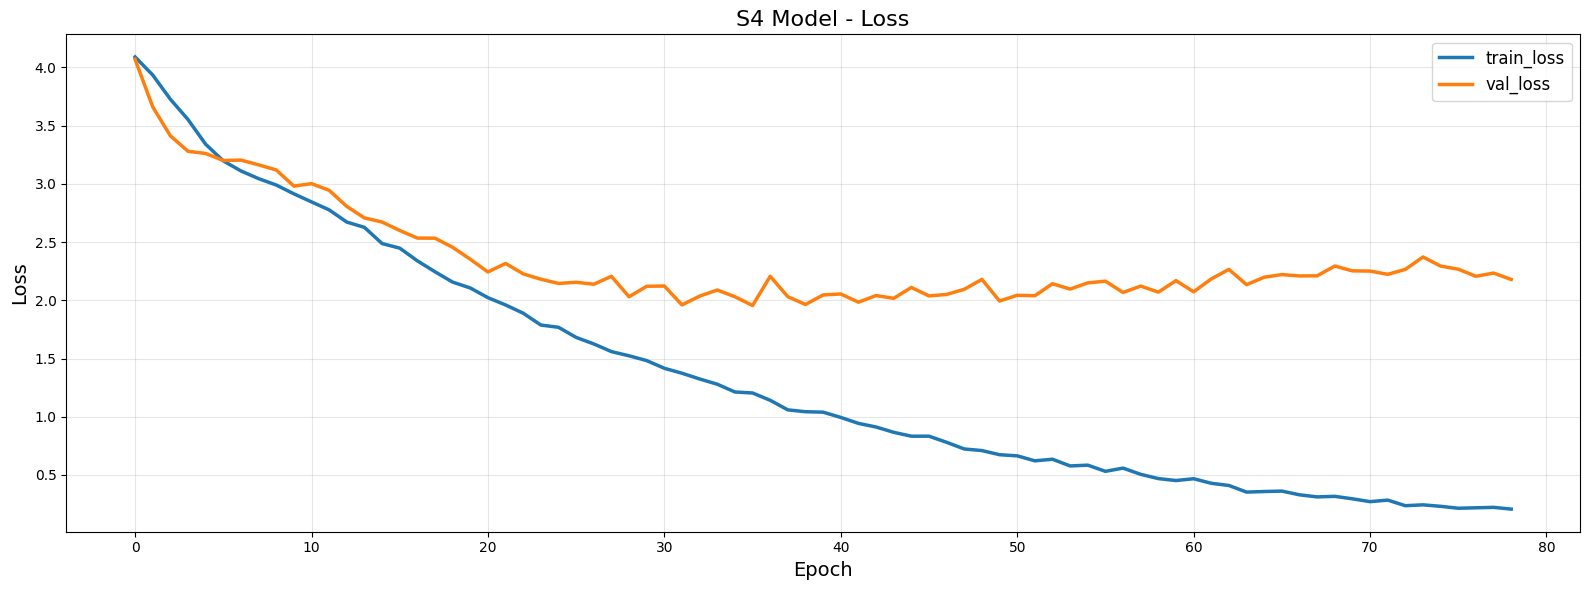

In [4]:
"""Visualize training history"""
from esc50_eval import plot_training_history
from src.utils.checkpoint import load_trainer_from_checkpoint

# Load trainer only for visualizing training history
trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=ESC50Task(),
)

plot_training_history(trainer, model_name="S4")

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...
✅ Loaded checkpoint from epoch 78
📊 Val metrics: {'loss': 2.1794225215911864, 'time_s': 3.8839452499996696, 'acc': 0.56}
ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecod

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(



✅ Validation results saved to: runs/esc50_s4_task/test_results.json
   Validation Accuracy: 0.5600 (56.00%)
   Validation Loss: 2.1794

VALIDATION SET RESULTS
Overall accuracy: 0.5600
Num classes: 50

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_30                  : 1.000
02. class_19                  : 1.000
03. class_9                   : 1.000
04. class_34                  : 1.000
05. class_18                  : 0.875
06. class_12                  : 0.750
07. class_3                   : 0.750
08. class_42                  : 0.750
09. class_39                  : 0.750
10. class_17                  : 0.750
Bottom per-class accuracies:
01. class_40                  : 0.125
02. class_15                  : 0.250
03. class_48                  : 0.250
04. class_46                  : 0.250
05. class_7                   : 0.250
06. class_35                  : 0.250
07. class_23                  : 0.250
08. class_45                  : 0.375
09. class_41  

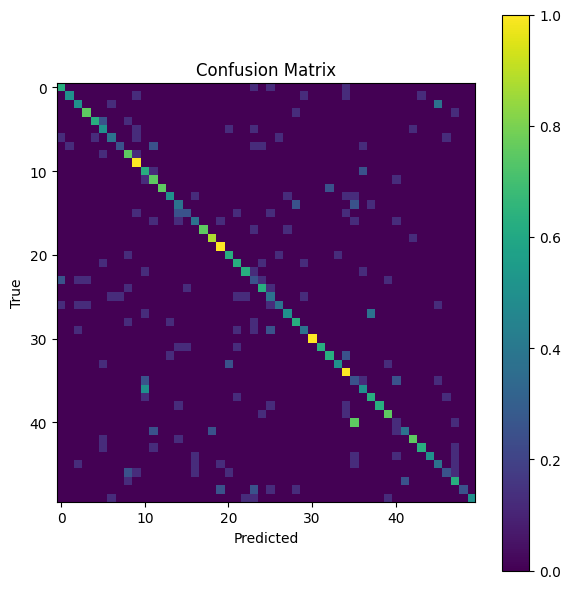

In [5]:
"""Detailed evaluation with confusion matrix"""
from esc50_eval import evaluate_best_model

best_model_path = args["save_dir"] + "/best.pt"
all_logits, all_labels = evaluate_best_model(
    args=args,
    task=ESC50Task(),
    best_model_path=best_model_path,
    num_classes=50,
    save_results=True
)

In [ ]:
from src.utils.common import print_model_details

print_model_details(model=trainer.model)

### Changes in dataset length


Training with fraction: 0.1
ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...
   Applying data fraction: 10.0%
   Original train size: 1600
   Original val size: 400


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ 

   Reduced train size: 150
   Reduced val size: 400
   Test size: 400 (unchanged)


...

Epoch 049/100 | train 2.0037/0.4297 | val 3.8655/0.1350 | t 2.8s/3.2s | lr 6.04e-04


Epoch 050/100 | train 1.9812/0.4062 | val 3.8298/0.1150 | t 2.8s/3.2s | lr 5.87e-04


Epoch 051/100 | train 1.8904/0.4688 | val 3.9022/0.1150 | t 2.9s/3.2s | lr 5.70e-04


Epoch 052/100 | train 1.7786/0.5234 | val 3.8623/0.1225 | t 2.9s/3.3s | lr 5.52e-04


⏹ Early stopping (patience=10, best=0.1450).
📊 Training history saved to ./runs/esc50_s4_task_frac_0.1/history.json

Training complete for fraction 0.1! Best validation acc: 0.1450
Best model saved to: ./runs/esc50_s4_task_frac_0.1/best.pt


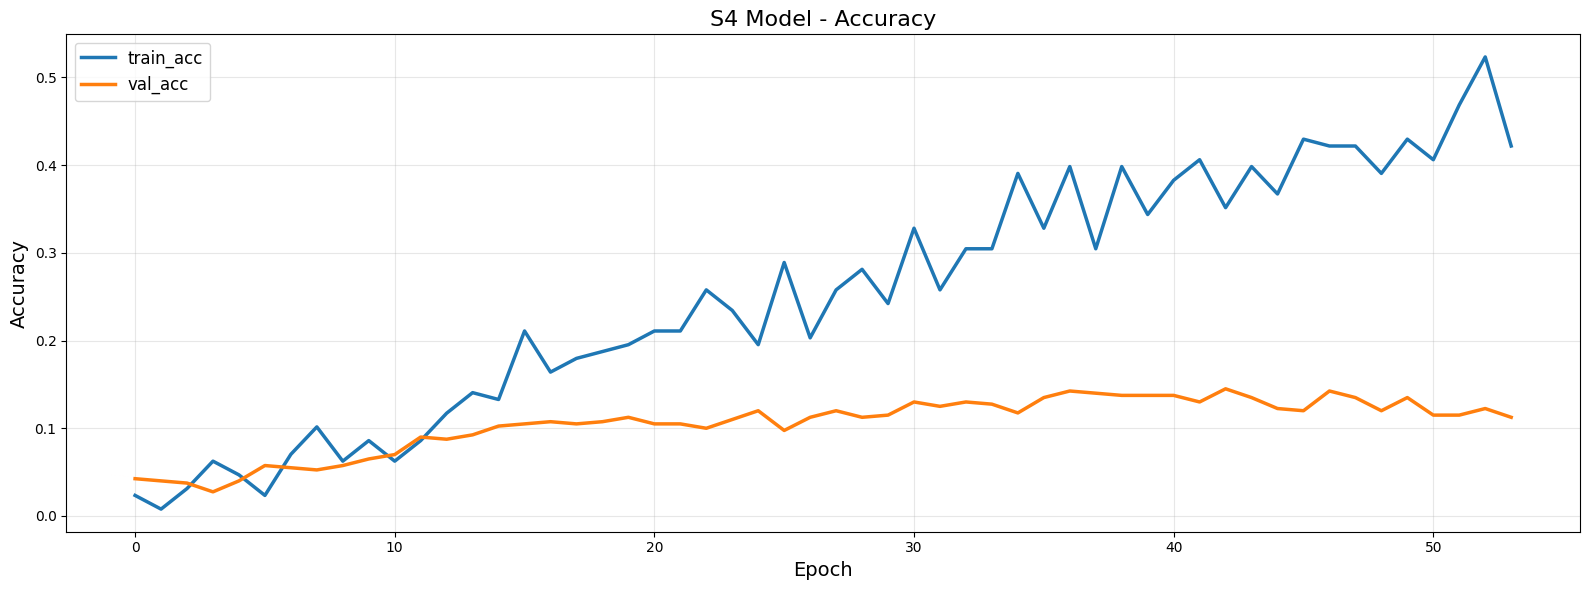

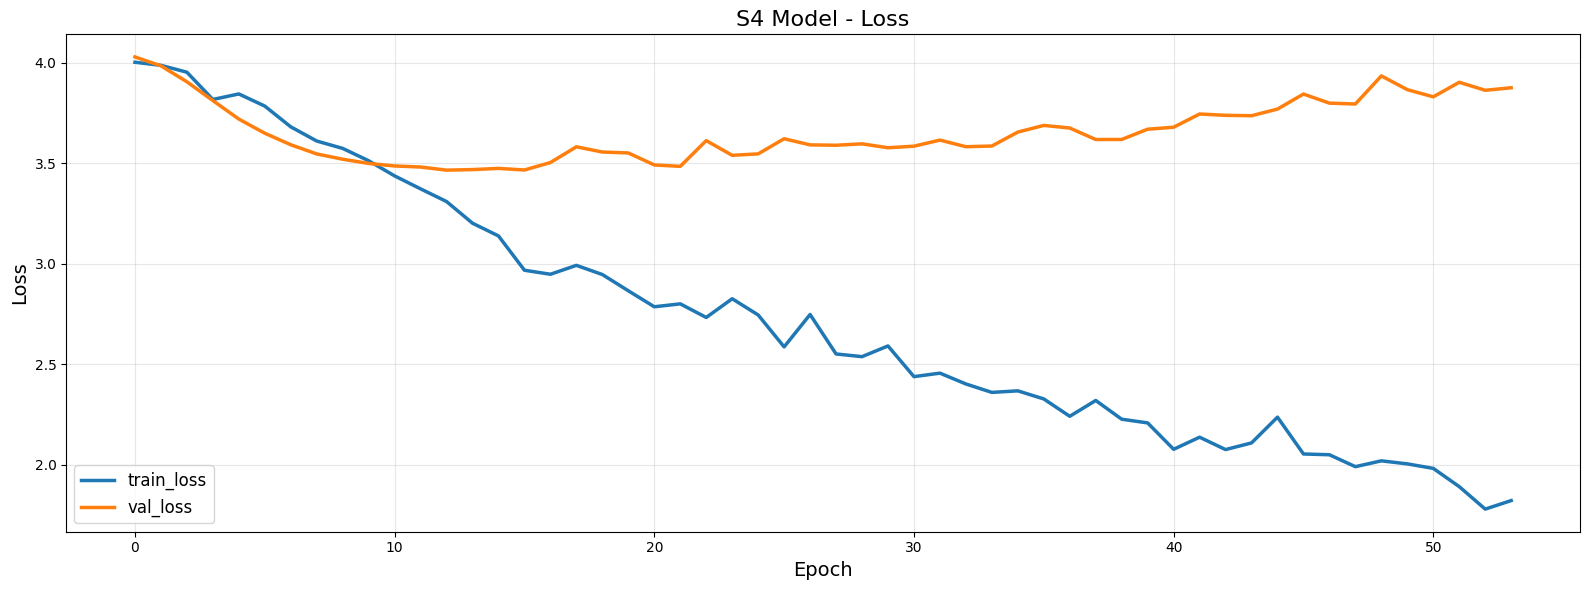

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...
   Applying data fraction: 10.0%
   Original train size: 1600
   Original val size: 400


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


   Reduced train size: 150
   Reduced val size: 400
   Test size: 400 (unchanged)
✅ Loaded checkpoint from epoch 42
📊 Val metrics: {'loss': 3.7377292251586915, 'time_s': 3.0413049160000014, 'acc': 0.145}
ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


...

Epoch 063/100 | train 1.2840/0.6302 | val 3.3262/0.2475 | t 8.7s/3.2s | lr 3.62e-04


Epoch 064/100 | train 1.2227/0.6510 | val 3.3685/0.2325 | t 8.9s/3.5s | lr 3.45e-04


Epoch 065/100 | train 1.2005/0.6589 | val 3.4051/0.2300 | t 8.9s/3.6s | lr 3.29e-04


Epoch 066/100 | train 1.1278/0.6875 | val 3.3842/0.2300 | t 8.8s/3.2s | lr 3.13e-04


⏹ Early stopping (patience=10, best=0.2575).
📊 Training history saved to ./runs/esc50_s4_task_frac_0.25/history.json

Training complete for fraction 0.25! Best validation acc: 0.2575
Best model saved to: ./runs/esc50_s4_task_frac_0.25/best.pt


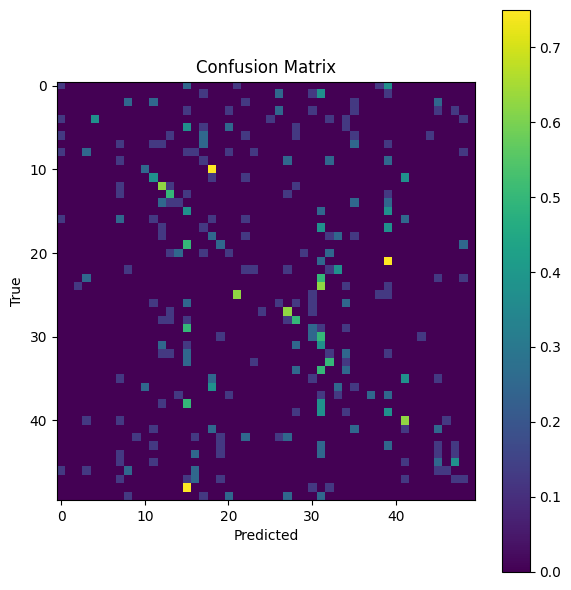

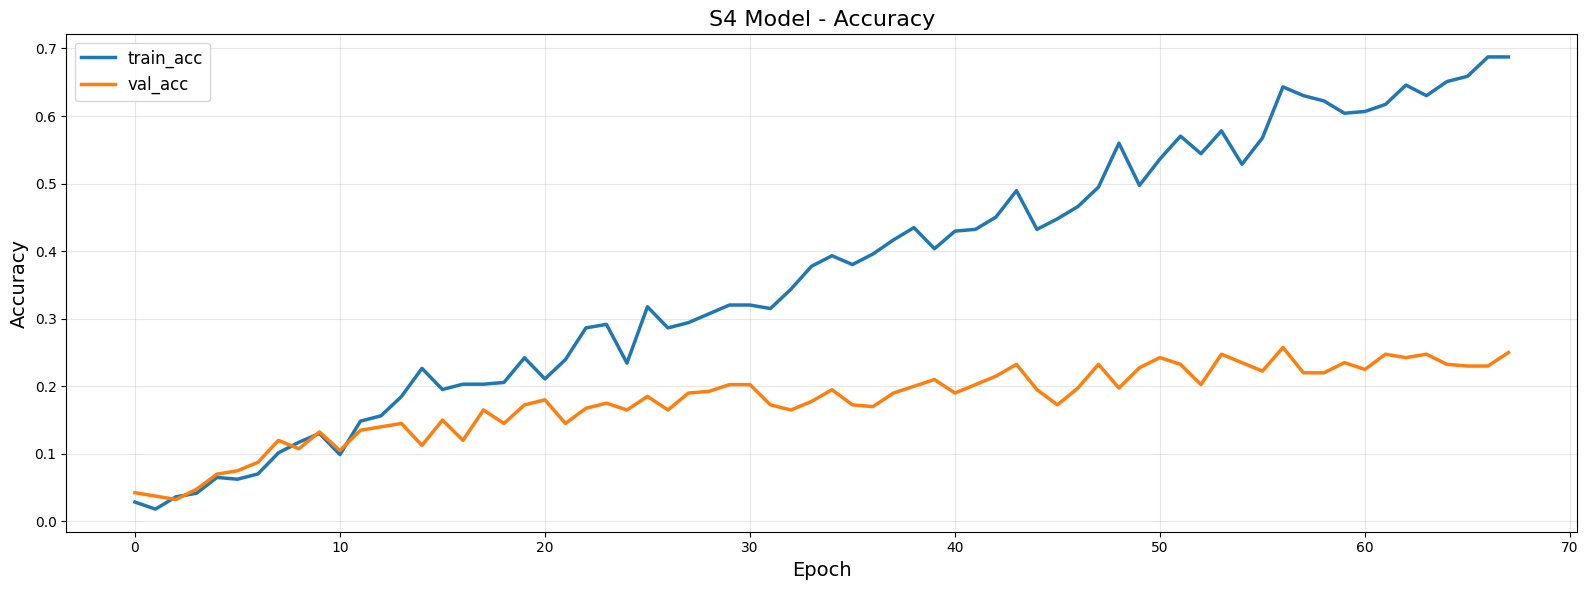

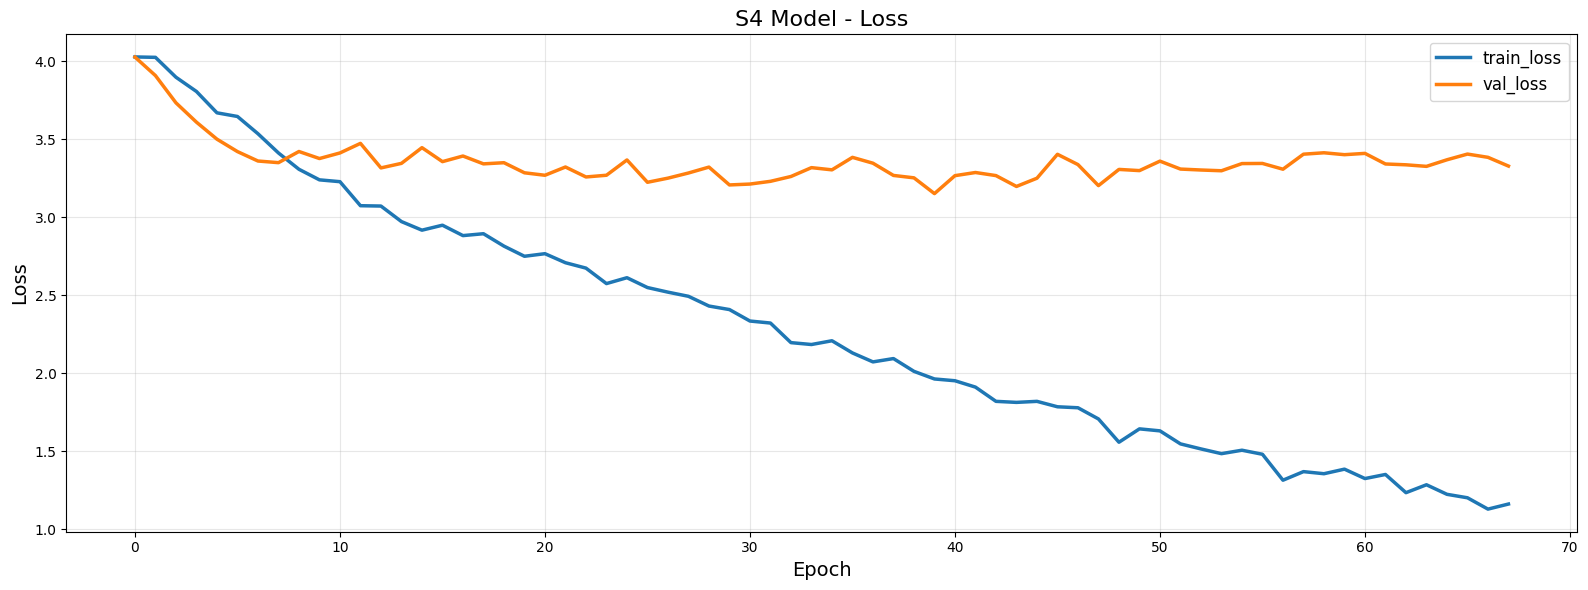

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...
   Applying data fraction: 25.0%
   Original train size: 1600
   Original val size: 400


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


   Reduced train size: 400
   Reduced val size: 400
   Test size: 400 (unchanged)
✅ Loaded checkpoint from epoch 56
📊 Val metrics: {'loss': 3.3079539489746095, 'time_s': 3.703679917000045, 'acc': 0.2575}
ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


...

Epoch 091/100 | train 0.4534/0.8912 | val 2.7023/0.4300 | t 19.0s/3.6s | lr 2.45e-05


Epoch 092/100 | train 0.4241/0.8875 | val 2.7011/0.4275 | t 19.0s/3.6s | lr 1.94e-05


Epoch 093/100 | train 0.4087/0.8988 | val 2.6992/0.4325 | t 19.2s/3.6s | lr 1.49e-05


Epoch 094/100 | train 0.4322/0.8862 | val 2.7019/0.4325 | t 19.1s/3.6s | lr 1.09e-05


⏹ Early stopping (patience=10, best=0.4400).
📊 Training history saved to ./runs/esc50_s4_task_frac_0.5/history.json

Training complete for fraction 0.5! Best validation acc: 0.4400
Best model saved to: ./runs/esc50_s4_task_frac_0.5/best.pt


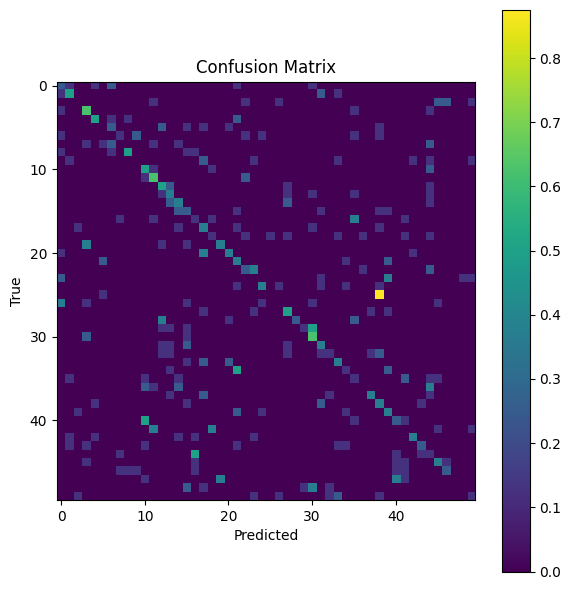

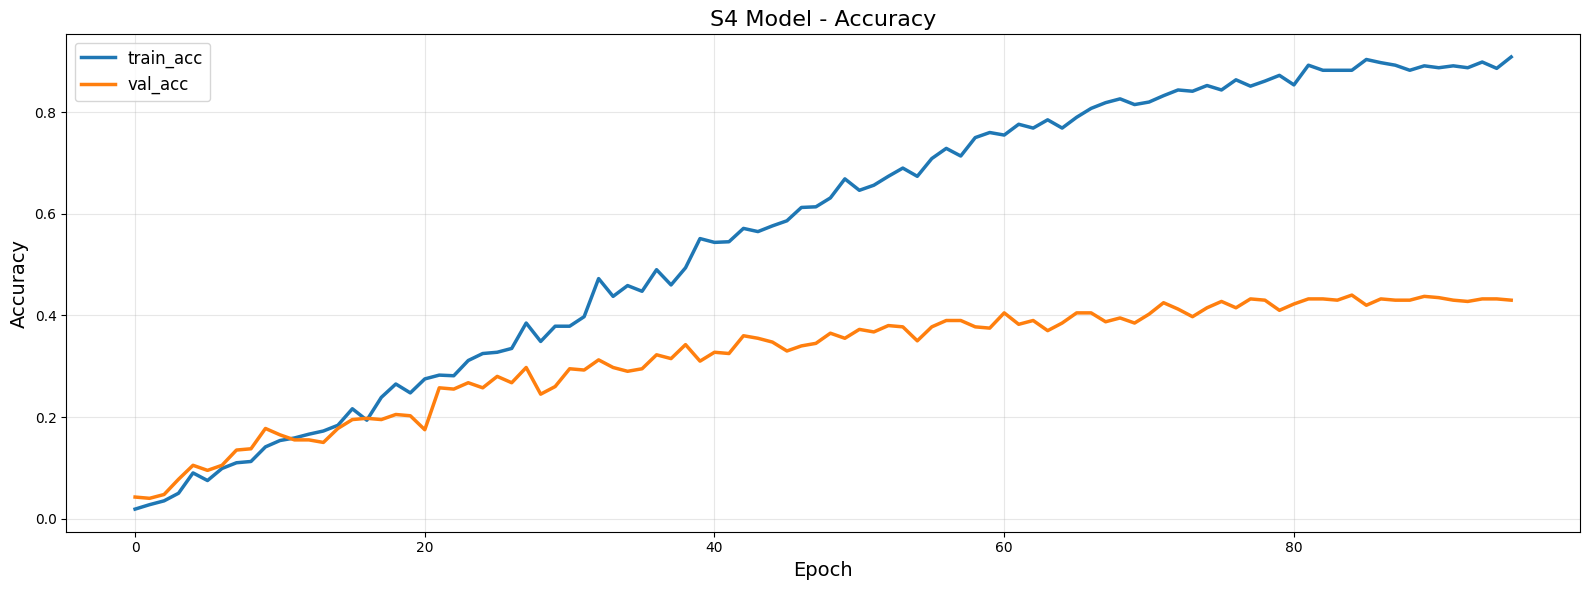

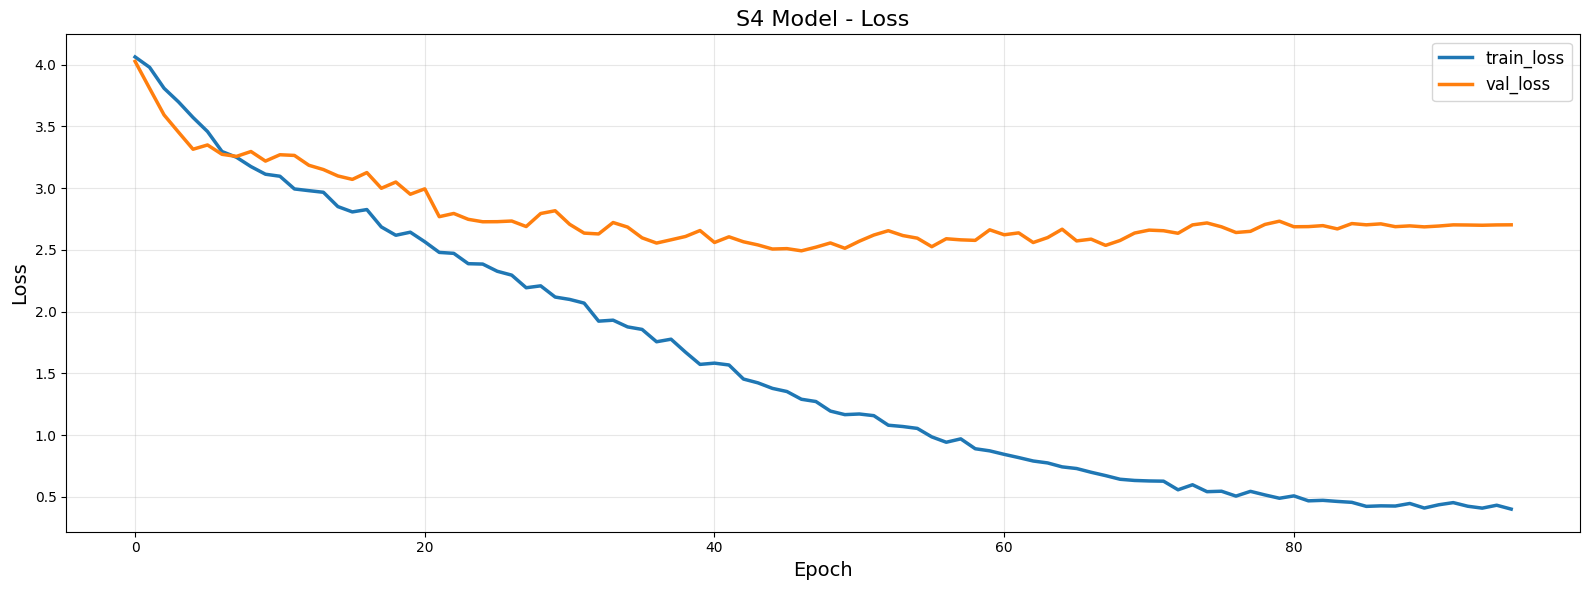

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...
   Applying data fraction: 50.0%
   Original train size: 1600
   Original val size: 400


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


   Reduced train size: 800
   Reduced val size: 400
   Test size: 400 (unchanged)
✅ Loaded checkpoint from epoch 84
📊 Val metrics: {'loss': 2.7127918720245363, 'time_s': 3.583560541999759, 'acc': 0.44}
ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecod

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(



✅ Validation results saved to: runs/esc50_s4_task_frac_0.5/test_results.json
   Validation Accuracy: 0.4400 (44.00%)
   Validation Loss: 2.7128

VALIDATION SET RESULTS
Overall accuracy: 0.4400
Num classes: 50

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_30                  : 1.000
02. class_9                   : 0.875
03. class_11                  : 0.875
04. class_43                  : 0.750
05. class_0                   : 0.750
06. class_10                  : 0.750
07. class_49                  : 0.625
08. class_8                   : 0.625
09. class_4                   : 0.625
10. class_17                  : 0.625
Bottom per-class accuracies:
01. class_25                  : 0.000
02. class_7                   : 0.000
03. class_41                  : 0.000
04. class_44                  : 0.125
05. class_36                  : 0.125
06. class_31                  : 0.125
07. class_26                  : 0.125
08. class_5                   : 0.125
09. c

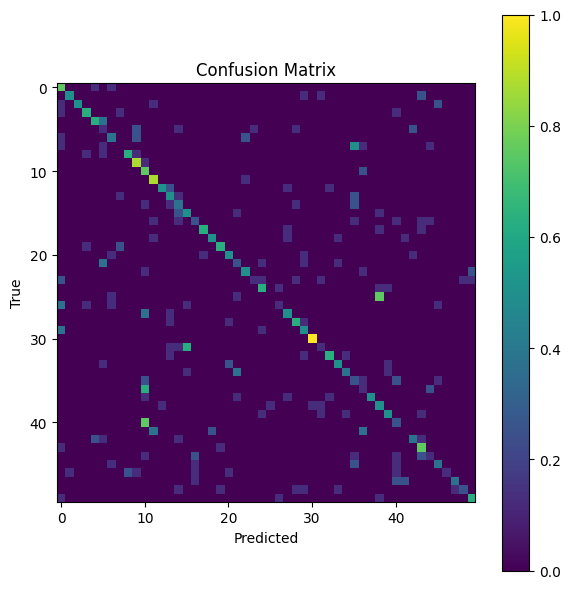

In [7]:
from src.train_utils.trainer import Trainer
from esc50_eval import evaluate_best_model
from esc50_eval import plot_training_history
import os

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"


for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/esc50_s4_task_frac_{frac}"
    trainer = Trainer(args=args, task=ESC50Task())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_training_history(trainer, model_name="S4")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=ESC50Task(),
        best_model_path=best_path,
        num_classes=50,
        save_results=True
    )